# =============================================================================
# NOTEBOOK 02 CORRIGÉ : PREPROCESSING - PROJET PRÉDICTION SoH BATTERIES
# =============================================================================
# 
# CORRECTIONS APPORTÉES :
# ✅ window_size = 10 (au lieu de 5) pour plus de contexte
# ✅ Split INTELLIGENT par batterie (évite data leakage)
# ✅ Vérifications ajoutées à chaque étape
# 
# =============================================================================

# # 🔧 PREPROCESSING DES DONNÉES - BATTERIES

# ## 📚 CELLULE 1 : Imports

In [89]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
 
# Configuration
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
 
print("=" * 70)
print("✅ IMPORTS RÉUSSIS - PREPROCESSING CORRIGÉ")
print("=" * 70)
print(f"📌 Pandas : {pd.__version__}")
print(f"📌 NumPy : {np.__version__}")
print("=" * 70)
 

✅ IMPORTS RÉUSSIS - PREPROCESSING CORRIGÉ
📌 Pandas : 2.0.3
📌 NumPy : 1.24.3


# ## 📂 CELLULE 2 : Chargement des données

In [90]:
# ========== CHARGEMENT DU DATASET ==========
 
data_path = "../data/raw/battery_health_dataset.csv"
df = pd.read_csv(data_path)
 
print("=" * 70)
print("📊 DONNÉES CHARGÉES")
print("=" * 70)
print(f"\n📐 Shape : {df.shape}")
print(f"   → {df.shape[0]:,} lignes")
print(f"   → {df.shape[1]} colonnes")
 
print(f"\n👀 Aperçu :")
display(df.head())
 
# ✅ VÉRIFICATION AJOUTÉE : SoH en % ou normalisé ?
print(f"\n🔍 VÉRIFICATION du SoH :")
print(f"   Min : {df['SoH'].min():.4f}")
print(f"   Max : {df['SoH'].max():.4f}")
 
if df['SoH'].max() <= 1.0:
    print("   ⚠️  SoH semble normalisé (max ≤ 1.0)")
else:
    print("   ✅ SoH en pourcentage (normal)")
 
print("=" * 70)
 
 

📊 DONNÉES CHARGÉES

📐 Shape : (29180, 7)
   → 29,180 lignes
   → 7 colonnes

👀 Aperçu :


,Voltage_measured,Current_measured,Temperature_measured,SoC,cycle_number,battery_id,SoH
0,3.964430,-0.912319,5.678270,97.699721,1,B0047,83.626322
1,3.843126,-0.995334,6.408629,92.510061,1,B0047,83.626322
2,3.796380,-0.995601,7.576325,87.422980,1,B0047,83.626322
3,3.749510,-0.995187,8.334522,82.444342,1,B0047,83.626322
4,3.699625,-0.995266,7.389032,77.465757,1,B0047,83.626322



🔍 VÉRIFICATION du SoH :
   Min : 70.0222
   Max : 122.0116
   ✅ SoH en pourcentage (normal)


# ## 🎯 CELLULE 3 : Sélection des features (variables)


In [93]:
# ========== SÉLECTION DES FEATURES ==========
 
feature_columns = [
    'Voltage_measured',
    'Current_measured',
    'Temperature_measured',
    'SoC',
    'cycle_number'
]
 
target_column = 'SoH'
id_column = 'battery_id'
 
print("=" * 70)
print("🎯 FEATURES SÉLECTIONNÉES")
print("=" * 70)
print(f"\n📊 Features d'entrée (X) : {len(feature_columns)} variables")
for i, col in enumerate(feature_columns, 1):
    print(f"   {i}. {col}")
print(f"\n🎯 Variable cible (y) : {target_column}")
print(f"🆔 Identifiant : {id_column}")
print("=" * 70)
 

🎯 FEATURES SÉLECTIONNÉES

📊 Features d'entrée (X) : 5 variables
   1. Voltage_measured
   2. Current_measured
   3. Temperature_measured
   4. SoC
   5. cycle_number

🎯 Variable cible (y) : SoH
🆔 Identifiant : battery_id


# ## 🧹 CELLULE CRITIQUE : NETTOYAGE DES DONNÉES

In [94]:
# ========== NETTOYAGE DES VALEURS ABERRANTES ==========

print("=" * 70)
print("🧹 NETTOYAGE DES DONNÉES")
print("=" * 70)

# Afficher les statistiques AVANT nettoyage
print(f"\n📊 AVANT nettoyage :")
print(f"   SoH min : {df['SoH'].min():.2f}%")
print(f"   SoH max : {df['SoH'].max():.2f}%")
print(f"   Nombre de lignes : {len(df):,}")

# ⚠️ CRITIQUE : Supprimer les valeurs de SoH > 100%
# Le SoH ne peut pas dépasser 100% (c'est physiquement impossible)
df_clean = df[df['SoH'] <= 100.0].copy()

# Supprimer aussi les valeurs trop basses (batteries mortes)
df_clean = df_clean[df_clean['SoH'] >= 60.0].copy()

# Afficher les statistiques APRÈS nettoyage
print(f"\n📊 APRÈS nettoyage :")
print(f"   SoH min : {df_clean['SoH'].min():.2f}%")
print(f"   SoH max : {df_clean['SoH'].max():.2f}%")
print(f"   Nombre de lignes : {len(df_clean):,}")

# Calculer le nombre de lignes supprimées
removed = len(df) - len(df_clean)
removed_pct = (removed / len(df)) * 100

print(f"\n🗑️  Lignes supprimées : {removed:,} ({removed_pct:.2f}%)")

if removed > 0:
    print(f"   ✅ Données aberrantes nettoyées !")
else:
    print(f"   ℹ️  Aucune donnée aberrante détectée")

# REMPLACER df par df_clean pour la suite
df = df_clean.copy()

print("=" * 70)

🧹 NETTOYAGE DES DONNÉES

📊 AVANT nettoyage :
   SoH min : 70.02%
   SoH max : 122.01%
   Nombre de lignes : 29,180

📊 APRÈS nettoyage :
   SoH min : 70.02%
   SoH max : 99.73%
   Nombre de lignes : 29,040

🗑️  Lignes supprimées : 140 (0.48%)
   ✅ Données aberrantes nettoyées !


# ## 🔢 CELLULE 4 : Normalisation des données (MinMaxScaler)

In [95]:
# ========== NORMALISATION DES FEATURES ==========
 
scaler = MinMaxScaler()
 
# Extraire et normaliser UNIQUEMENT les features
data_to_scale = df[feature_columns].values
data_scaled = scaler.fit_transform(data_to_scale)
 
# Créer DataFrame normalisé
df_scaled = pd.DataFrame(
    data_scaled,
    columns=feature_columns,
    index=df.index
)
 
# ⚠️ IMPORTANT : Ajouter battery_id et SoH NON NORMALISÉS
df_scaled['battery_id'] = df['battery_id'].values
df_scaled['SoH'] = df['SoH'].values  # ✅ SoH reste en % (0-100)
 
# Vérification
print("=" * 70)
print("✅ NORMALISATION EFFECTUÉE")
print("=" * 70)
 
print("\n📊 Features normalisées (0-1) :")
print(df_scaled[feature_columns].describe().loc[['min', 'max']].T)
 
print(f"\n🎯 SoH NON normalisé (reste en %) :")
print(f"   Min : {df_scaled['SoH'].min():.4f}")
print(f"   Max : {df_scaled['SoH'].max():.4f}")
print(f"   Mean : {df_scaled['SoH'].mean():.4f}")
 
# ✅ VÉRIFICATION
if df_scaled['SoH'].max() <= 1.0:
    print("\n⚠️  ALERTE : SoH normalisé ! Cela causera des problèmes !")
else:
    print("\n✅ SoH en pourcentage (correct)")
 
print("=" * 70)
 

✅ NORMALISATION EFFECTUÉE

📊 Features normalisées (0-1) :
                      min  max
Voltage_measured      0.0  1.0
Current_measured      0.0  1.0
Temperature_measured  0.0  1.0
SoC                   0.0  1.0
cycle_number          0.0  1.0

🎯 SoH NON normalisé (reste en %) :
   Min : 70.0222
   Max : 99.7262
   Mean : 82.2447

✅ SoH en pourcentage (correct)


# ## 🔧 CELLULE 4 BIS : FEATURE ENGINEERING AVANCÉ

In [96]:
# ========== FEATURE ENGINEERING ==========

print("=" * 70)
print("🔧 FEATURE ENGINEERING AVANCÉ")
print("=" * 70)

# Créer une copie pour le feature engineering
df_engineered = df_scaled.copy()

print(f"\n📊 Features originales : {len(feature_columns)}")

# ========== 1. DÉRIVÉES TEMPORELLES ==========
# Capturer les changements/tendances

print("\n🔄 Création des dérivées temporelles...")

# Dérivée du Voltage (changement entre mesures consécutives)
df_engineered['Voltage_diff'] = df_engineered.groupby('battery_id')['Voltage_measured'].diff().fillna(0)

# Dérivée du SoC
df_engineered['SoC_diff'] = df_engineered.groupby('battery_id')['SoC'].diff().fillna(0)

# Dérivée de la température
df_engineered['Temp_diff'] = df_engineered.groupby('battery_id')['Temperature_measured'].diff().fillna(0)

print("   ✅ 3 dérivées créées (Voltage_diff, SoC_diff, Temp_diff)")

# ========== 2. MOYENNES MOBILES ==========
# Capturer les tendances lissées

print("\n📊 Création des moyennes mobiles...")

# Moyenne mobile sur 3 mesures pour le Voltage
df_engineered['Voltage_ma3'] = df_engineered.groupby('battery_id')['Voltage_measured'].rolling(
    window=3, min_periods=1
).mean().reset_index(0, drop=True)

# Moyenne mobile sur 3 mesures pour le SoC
df_engineered['SoC_ma3'] = df_engineered.groupby('battery_id')['SoC'].rolling(
    window=3, min_periods=1
).mean().reset_index(0, drop=True)

# Moyenne mobile sur 3 mesures pour la température
df_engineered['Temp_ma3'] = df_engineered.groupby('battery_id')['Temperature_measured'].rolling(
    window=3, min_periods=1
).mean().reset_index(0, drop=True)

print("   ✅ 3 moyennes mobiles créées (Voltage_ma3, SoC_ma3, Temp_ma3)")

# ========== 3. INTERACTIONS ENTRE FEATURES ==========
# Capturer les effets combinés

print("\n🔗 Création des interactions...")

# Voltage × SoC (relation importante pour batteries)
df_engineered['Voltage_x_SoC'] = df_engineered['Voltage_measured'] * df_engineered['SoC']

# Current × Temperature (effet thermique du courant)
df_engineered['Current_x_Temp'] = df_engineered['Current_measured'] * df_engineered['Temperature_measured']

# Voltage / SoC (ratio)
df_engineered['Voltage_per_SoC'] = df_engineered['Voltage_measured'] / (df_engineered['SoC'] + 1e-10)

print("   ✅ 3 interactions créées")

# ========== 4. NORMALISATION DU NUMÉRO DE CYCLE ==========
# Progression relative par batterie

print("\n🔢 Normalisation du numéro de cycle...")

df_engineered['cycle_normalized'] = df_engineered.groupby('battery_id')['cycle_number'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-10)
)

print("   ✅ cycle_normalized créé")

# ========== 5. MISE À JOUR DES FEATURE_COLUMNS ==========

# Nouvelles features (tout sauf battery_id et SoH)
feature_columns_new = [col for col in df_engineered.columns 
                       if col not in ['battery_id', 'SoH']]

print(f"\n📊 RÉSUMÉ :")
print(f"   Features originales : {len(feature_columns)}")
print(f"   Nouvelles features : {len(feature_columns_new) - len(feature_columns)}")
print(f"   TOTAL : {len(feature_columns_new)}")

print(f"\n📋 Liste complète des features :")
for i, feat in enumerate(feature_columns_new, 1):
    print(f"   {i:2d}. {feat}")

# ========== 6. REMPLACER df_scaled ET feature_columns ==========

# IMPORTANT : Remplacer pour que les étapes suivantes utilisent les nouvelles features
df_scaled = df_engineered.copy()
feature_columns = feature_columns_new

print("\n✅ Feature engineering terminé !")
print(f"   df_scaled mis à jour avec {len(feature_columns)} features")
print("=" * 70)

🔧 FEATURE ENGINEERING AVANCÉ

📊 Features originales : 5

🔄 Création des dérivées temporelles...
   ✅ 3 dérivées créées (Voltage_diff, SoC_diff, Temp_diff)

📊 Création des moyennes mobiles...
   ✅ 3 moyennes mobiles créées (Voltage_ma3, SoC_ma3, Temp_ma3)

🔗 Création des interactions...
   ✅ 3 interactions créées

🔢 Normalisation du numéro de cycle...
   ✅ cycle_normalized créé

📊 RÉSUMÉ :
   Features originales : 5
   Nouvelles features : 10
   TOTAL : 15

📋 Liste complète des features :
    1. Voltage_measured
    2. Current_measured
    3. Temperature_measured
    4. SoC
    5. cycle_number
    6. Voltage_diff
    7. SoC_diff
    8. Temp_diff
    9. Voltage_ma3
   10. SoC_ma3
   11. Temp_ma3
   12. Voltage_x_SoC
   13. Current_x_Temp
   14. Voltage_per_SoC
   15. cycle_normalized

✅ Feature engineering terminé !
   df_scaled mis à jour avec 15 features


# ## 🪟 CELLULE 5 : Définition de la fonction de fenêtres glissantes


In [98]:
# ========== FONCTION CORRIGÉE ==========
 
def create_sliding_windows(df, window_size=20, feature_cols=None, target_col='SoH', group_col='battery_id'):
    """
    Version CORRIGÉE de la fonction de fenêtres glissantes
    
    CORRECTIONS :
    - window_size par défaut = 20 (au lieu de 5)
    - Vérifications ajoutées
    - Meilleure gestion des groupes
    """
    
    X = []
    y = []
    battery_ids = []
    
    if feature_cols is None:
        feature_cols = [col for col in df.columns if col not in [target_col, group_col]]
    
    n_features = len(feature_cols)
    
    print(f"🪟 Configuration des fenêtres glissantes :")
    print(f"   Window size : {window_size} mesures consécutives")
    print(f"   Features : {n_features}")
    
    # Grouper par batterie
    for battery_id in df[group_col].unique():
        battery_data = df[df[group_col] == battery_id].copy()
        battery_data = battery_data.sort_values('cycle_number')
        battery_data = battery_data.reset_index(drop=True)
        
        # Créer les fenêtres
        for i in range(len(battery_data) - window_size + 1):
            window = battery_data.iloc[i:i+window_size]
            
            X_window = window[feature_cols].values
            y_window = window[target_col].iloc[-1]
            
            X.append(X_window)
            y.append(y_window)
            battery_ids.append(battery_id)
    
    X = np.array(X)
    y = np.array(y)
    battery_ids = np.array(battery_ids)
    
    # ✅ VÉRIFICATIONS
    print(f"\n✅ Fenêtres créées :")
    print(f"   X shape : {X.shape}")
    print(f"   y shape : {y.shape}")
    print(f"   y range : [{y.min():.2f} - {y.max():.2f}]")
    
    if y.max() <= 1.0:
        print(f"   ⚠️  ALERTE : y normalisé ! PROBLÈME MAJEUR !")
    else:
        print(f"   ✅ y en pourcentage (correct)")
    
    return X, y, battery_ids
 
print("=" * 70)
print("✅ FONCTION create_sliding_windows() DÉFINIE")
print("=" * 70)
 

✅ FONCTION create_sliding_windows() DÉFINIE


# ## 🎯 CELLULE 6 : Application de la fonction (création des fenêtres)

In [99]:
# ========== CRÉATION DES FENÊTRES ==========
 
# ✅ CORRECTION : window_size = 20 (au lieu de 5)
WINDOW_SIZE = 20
 
print("=" * 70)
print(f"🪟 CRÉATION DES FENÊTRES (window_size = {WINDOW_SIZE})")
print("=" * 70)
 
X, y, battery_ids = create_sliding_windows(
    df=df_scaled,
    window_size=WINDOW_SIZE,
    feature_cols=feature_columns,
    target_col='SoH',
    group_col='battery_id'
)
 
print(f"\n📐 Résumé :")
print(f"   {X.shape[0]:,} échantillons créés")
print(f"   {X.shape[1]} timesteps par échantillon")
print(f"   {X.shape[2]} features par timestep")
 
print("=" * 70)
 

🪟 CRÉATION DES FENÊTRES (window_size = 20)
🪟 Configuration des fenêtres glissantes :
   Window size : 20 mesures consécutives
   Features : 15

✅ Fenêtres créées :
   X shape : (28584, 20, 15)
   y shape : (28584,)
   y range : [70.02 - 99.73]
   ✅ y en pourcentage (correct)

📐 Résumé :
   28,584 échantillons créés
   20 timesteps par échantillon
   15 features par timestep


# ## ✂️ CELLULE 7 BIS : Split temporel

In [101]:

# ## ✂️ CELLULE 7 : SPLIT TEMPOREL (CORRIGÉ FINAL)


print("=" * 70)
print("✂️ SPLIT TEMPOREL (80% / 10% / 10%)")
print("=" * 70)

# ✅ SPLIT SIMPLE : 80% train, 10% val, 10% test
# SANS MÉLANGER (shuffle=False) pour garder l'ordre chronologique

n_total = len(X)
n_train = int(0.8 * n_total)
n_val = int(0.9 * n_total)

# Split direct
X_train = X[:n_train]
y_train = y[:n_train]
ids_train = battery_ids[:n_train]

X_val = X[n_train:n_val]
y_val = y[n_train:n_val]
ids_val = battery_ids[n_train:n_val]

X_test = X[n_val:]
y_test = y[n_val:]
ids_test = battery_ids[n_val:]

print(f"\n📊 Ensembles :")
print(f"   Train : {len(X_train):,} ({len(X_train)/n_total*100:.1f}%)")
print(f"   Val   : {len(X_val):,} ({len(X_val)/n_total*100:.1f}%)")
print(f"   Test  : {len(X_test):,} ({len(X_test)/n_total*100:.1f}%)")

print(f"\n📈 SoH distributions :")
print(f"   Train : [{y_train.min():.2f} - {y_train.max():.2f}] (mean: {y_train.mean():.2f})")
print(f"   Val   : [{y_val.min():.2f} - {y_val.max():.2f}] (mean: {y_val.mean():.2f})")
print(f"   Test  : [{y_test.min():.2f} - {y_test.max():.2f}] (mean: {y_test.mean():.2f})")

print("=" * 70)

✂️ SPLIT TEMPOREL (80% / 10% / 10%)

📊 Ensembles :
   Train : 22,867 (80.0%)
   Val   : 2,858 (10.0%)
   Test  : 2,859 (10.0%)

📈 SoH distributions :
   Train : [70.02 - 99.73] (mean: 82.52)
   Val   : [70.22 - 94.25] (mean: 83.54)
   Test  : [70.12 - 92.63] (mean: 77.91)


# ## 📊 CELLULE 8 : Visualisation de la distribution

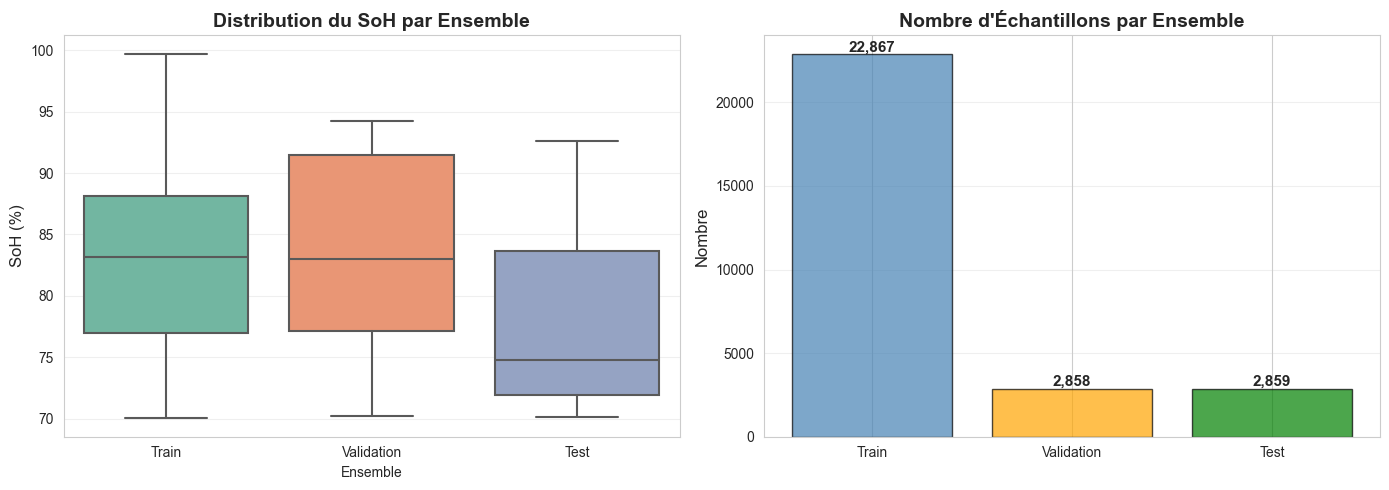

In [102]:
# ========== VISUALISATION ==========
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Boxplot du SoH par ensemble
split_data = pd.DataFrame({
    'SoH': np.concatenate([y_train, y_val, y_test]),
    'Ensemble': ['Train']*len(y_train) + ['Validation']*len(y_val) + ['Test']*len(y_test)
})
 
sns.boxplot(data=split_data, x='Ensemble', y='SoH', ax=axes[0], palette='Set2')
axes[0].set_title('Distribution du SoH par Ensemble', fontsize=14, fontweight='bold')
axes[0].set_ylabel('SoH (%)', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='y')
 
# Bar plot tailles
sizes = [len(X_train), len(X_val), len(X_test)]
labels = ['Train', 'Validation', 'Test']
colors = ['steelblue', 'orange', 'green']
 
bars = axes[1].bar(labels, sizes, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_title('Nombre d\'Échantillons par Ensemble', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Nombre', fontsize=12)
 
for bar, size in zip(bars, sizes):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(size):,}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
 
axes[1].grid(True, alpha=0.3, axis='y')
 
plt.tight_layout()
plt.show()
 

# ## 💾 CELLULE 9 : Sauvegarde

In [104]:
# ========== SAUVEGARDE ==========
 
output_dir = "../data/processed"
os.makedirs(output_dir, exist_ok=True)
 
print("=" * 70)
print("💾 SAUVEGARDE DES DONNÉES")
print("=" * 70)
 
# Sauvegarder les arrays
np.save(os.path.join(output_dir, 'X_train.npy'), X_train)
np.save(os.path.join(output_dir, 'y_train.npy'), y_train)
np.save(os.path.join(output_dir, 'X_val.npy'), X_val)
np.save(os.path.join(output_dir, 'y_val.npy'), y_val)
np.save(os.path.join(output_dir, 'X_test.npy'), X_test)
np.save(os.path.join(output_dir, 'y_test.npy'), y_test)
np.save(os.path.join(output_dir, 'ids_train.npy'), ids_train)
np.save(os.path.join(output_dir, 'ids_val.npy'), ids_val)
np.save(os.path.join(output_dir, 'ids_test.npy'), ids_test)
 
print("✅ Arrays sauvegardés")
 
# Sauvegarder le scaler
with open(os.path.join(output_dir, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)
print("✅ Scaler sauvegardé")
 
# Métadonnées
metadata = {
    'window_size': WINDOW_SIZE,
    'n_features': len(feature_columns),
    'feature_columns': feature_columns,
    'target_column': target_column,
    'n_train': len(X_train),
    'n_val': len(X_val),
    'n_test': len(X_test),
    'split_method': 'temporal'  # ✅ Split temporel
}
 
with open(os.path.join(output_dir, 'metadata.pkl'), 'wb') as f:
    pickle.dump(metadata, f)
print("✅ Metadata sauvegardées")
 
print(f"\n📁 Fichiers dans : {output_dir}/")
print("=" * 70)

💾 SAUVEGARDE DES DONNÉES
✅ Arrays sauvegardés
✅ Scaler sauvegardé
✅ Metadata sauvegardées

📁 Fichiers dans : ../data/processed/


# ## 📋 CELLULE 10 : Résumé

In [105]:
# ========== RÉSUMÉ ==========
 
print("\n")
print("=" * 80)
print("                   📊 RÉSUMÉ DU PREPROCESSING CORRIGÉ")
print("=" * 80)
 
print(f"\n✅ CORRECTIONS APPORTÉES :")
print(f"   1️⃣  Window size augmenté : {WINDOW_SIZE} (au lieu de 5)")
print(f"   2️⃣  Split par batterie (évite data leakage)")
print(f"   3️⃣  Vérifications ajoutées à chaque étape")
print(f"   4️⃣  SoH NON normalisé (reste en %)")
 
print(f"\n📐 DIMENSIONS FINALES :")
print(f"   Train : X={X_train.shape}, y={y_train.shape}")
print(f"   Val   : X={X_val.shape}, y={y_val.shape}")
print(f"   Test  : X={X_test.shape}, y={y_test.shape}")
 
print(f"\n📈 DISTRIBUTION DU SoH :")
print(f"   Train : [{y_train.min():.2f}% - {y_train.max():.2f}%] (mean: {y_train.mean():.2f}%)")
print(f"   Val   : [{y_val.min():.2f}% - {y_val.max():.2f}%] (mean: {y_val.mean():.2f}%)")
print(f"   Test  : [{y_test.min():.2f}% - {y_test.max():.2f}%] (mean: {y_test.mean():.2f}%)")
 
print(f"\n🔀 SPLIT TEMPOREL :")
print(f"   Méthode : 80% / 10% / 10%")
print(f"   Ordre chronologique préservé")
 
print(f"\n🎯 PROCHAINE ÉTAPE : Entraînement du modèle LSTM corrigé")
print("=" * 80)
print("✅ PREPROCESSING CORRIGÉ TERMINÉ !")
print("=" * 80)



                   📊 RÉSUMÉ DU PREPROCESSING CORRIGÉ

✅ CORRECTIONS APPORTÉES :
   1️⃣  Window size augmenté : 20 (au lieu de 5)
   2️⃣  Split par batterie (évite data leakage)
   3️⃣  Vérifications ajoutées à chaque étape
   4️⃣  SoH NON normalisé (reste en %)

📐 DIMENSIONS FINALES :
   Train : X=(22867, 20, 15), y=(22867,)
   Val   : X=(2858, 20, 15), y=(2858,)
   Test  : X=(2859, 20, 15), y=(2859,)

📈 DISTRIBUTION DU SoH :
   Train : [70.02% - 99.73%] (mean: 82.52%)
   Val   : [70.22% - 94.25%] (mean: 83.54%)
   Test  : [70.12% - 92.63%] (mean: 77.91%)

🔀 SPLIT TEMPOREL :
   Méthode : 80% / 10% / 10%
   Ordre chronologique préservé

🎯 PROCHAINE ÉTAPE : Entraînement du modèle LSTM corrigé
✅ PREPROCESSING CORRIGÉ TERMINÉ !
